# 07 · Candidato al sistema final

**Objetivo.** Integrar el retrieval mejorado, ejecutar el golden completo y comparar el candidato con el baseline sin ocultar la dependencia pendiente del notebook 06.

Este notebook distingue tres estados:

- `baseline`: referencia histórica, ya guardada.
- `candidato_07`: retrieval mejorado **sin guardrails**; sus métricas son provisionales.
- `final`: retrieval mejorado + middleware del 06; debe fallar mientras ese middleware no esté disponible.

Con `EJECUTAR=False` no llama a OpenRouter y funciona aunque todavía no exista `resultados/candidato_07/`. Con `True` evalúa las 20 preguntas, no una selección. Requisitos: R10–R12; R04–R05 quedan pendientes del 06.

In [1]:
# Arranque independiente del directorio desde el que se abrió Jupyter.
import json
import pathlib
import sys

RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'pyproject.toml').is_file())
if str(RAIZ / 'src') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'src'))

from IPython.display import Markdown, display
from agente10k import config
from agente10k.agente import SistemaFinalNoDisponible, _componentes_sistema
from agente10k.evaluacion import cargar_golden, evaluar, tabla_comparativa, validar_golden

print('Raíz:', RAIZ)
print('Paquete:', pathlib.Path(__import__('agente10k').__file__).resolve())

Raíz: C:\Users\Usuario\Downloads\10k-financial-agent
Paquete: C:\Users\Usuario\Downloads\10k-financial-agent\src\agente10k\__init__.py


In [2]:
# Cambiar a True únicamente para una ejecución real y completa con OpenRouter.
EJECUTAR = False
ETIQUETA_CANDIDATO = 'candidato_07'
RUTA_GOLDEN = config.GOLDEN / 'golden_propio.jsonl'
RUTA_RETRIEVAL = config.RESULTADOS / 'retrieval' / '5976eb180c38'

if EJECUTAR:
    assert config.cargar_clave(), 'Falta OPENROUTER_API_KEY en el entorno o en .env'
    if (config.RESULTADOS / ETIQUETA_CANDIDATO / 'predicciones.jsonl').is_file():
        print('Aviso: evaluar() reutilizará las predicciones existentes de la etiqueta.')

## 1. Entradas y contratos

Antes de comparar sistemas se valida el mismo golden que usa la evaluación. El 07 no modifica el golden, el corpus ni los resultados históricos.

In [3]:
preguntas = cargar_golden(RUTA_GOLDEN)
problemas = validar_golden(preguntas)
familias = {familia: sum(p['familia'] == familia for p in preguntas) for familia in ('numerica', 'extractiva', 'comparativa')}
assert not problemas, problemas
display(Markdown(f'**Golden válido:** {len(preguntas)} preguntas · {familias}'))

**Golden válido:** 20 preguntas · {'numerica': 7, 'extractiva': 6, 'comparativa': 7}

## 2. Arquitectura: candidato disponible, final protegido

El candidato sustituye únicamente `search_filings` por su variante mejorada y conserva los nombres públicos de las cuatro herramientas. `final` usa el mismo retrieval y exige además una pila de middleware no vacía procedente del 06.

In [4]:
tools_baseline, middleware_baseline = _componentes_sistema('baseline')
tools_candidato, middleware_candidato = _componentes_sistema('candidato_07')
nombres_baseline = [tool.name for tool in tools_baseline]
nombres_candidato = [tool.name for tool in tools_candidato]
assert nombres_baseline == nombres_candidato
assert not middleware_baseline and not middleware_candidato
print('Contrato de tools conservado:', nombres_candidato)
print('search_filings sustituida:', tools_baseline[nombres_baseline.index('search_filings')] is not tools_candidato[nombres_candidato.index('search_filings')])

Contrato de tools conservado: ['list_available', 'get_xbrl_fact', 'search_filings', 'read_section']
search_filings sustituida: True


In [5]:
# Esta celda documenta el estado real; no convierte el candidato en final.
try:
    _, middleware_final = _componentes_sistema('final')
except SistemaFinalNoDisponible as exc:
    ESTADO_FINAL = f'PENDIENTE: {exc}'
else:
    assert middleware_final, 'El sistema final no puede tener middleware vacío'
    ESTADO_FINAL = f'DISPONIBLE: {len(middleware_final)} componentes de middleware'
display(Markdown(f'**Estado del sistema final:** {ESTADO_FINAL}'))

**Estado del sistema final:** DISPONIBLE: 4 componentes de middleware

## 3. Evidencia de retrieval seleccionada

Se lee el artefacto completo del notebook 05. El recall aislado no se confunde con el acierto extremo a extremo. El experimento manual 12/13 es exploratorio y no entra en esta tabla.

In [6]:
ruta_resumen_retrieval = RUTA_RETRIEVAL / 'resumen.json'
if ruta_resumen_retrieval.is_file():
    resumen_retrieval = json.loads(ruta_resumen_retrieval.read_text(encoding='utf-8'))
    assert resumen_retrieval.get('completo'), resumen_retrieval
    assert resumen_retrieval.get('fallos_reescritura', 0) == 0, resumen_retrieval
    filas = ['| Paso | Aciertos@5 | Recall@5 |', '| --- | ---: | ---: |']
    for paso in resumen_retrieval['pasos'][:4]:
        filas.append(f"| {paso['paso']} | {paso['aciertos@5']} | {paso['recall@5']:.3f} |")
    display(Markdown('\n'.join(filas)))
else:
    resumen_retrieval = {}
    display(Markdown('⚠️ No está disponible el resumen de retrieval seleccionado.'))

| Paso | Aciertos@5 | Recall@5 |
| --- | ---: | ---: |
| 0_denso | 2/13 | 0.154 |
| 1_filtro | 4/13 | 0.308 |
| 2_bm25 | 5/13 | 0.385 |
| 3_reescritura | 5/13 | 0.385 |

## 4. Evaluación real del candidato

Al activar `EJECUTAR`, esta celda llama a OpenRouter para las 20 preguntas y guarda los artefactos bajo `resultados/candidato_07/`. La etiqueta deja claro que todavía no hay guardrails.

In [7]:
if EJECUTAR:
    puntuaciones_candidato = evaluar(RUTA_GOLDEN, etiqueta=ETIQUETA_CANDIDATO, sistema='candidato_07')
    display(puntuaciones_candidato)
else:
    print('EJECUTAR=False: no se realizan llamadas. Se reutilizan solo artefactos ya guardados.')

EJECUTAR=False: no se realizan llamadas. Se reutilizan solo artefactos ya guardados.


## 5. Comparación

La función devuelve `disponible=False` si falta una ejecución, en vez de inventar ceros. Las columnas `mejor_*` solo se activan cuando hay dos resultados comparables. Coste ausente significa desconocido, no gratuito. `final` entra en la comparación automáticamente en cuanto exista `resultados/final/resumen.json` (comprobado con `Path.exists()`, nunca asumido).

**Qué es cada fila (docs/13 §1, CLAUDE.md regla 7):**

| Fila | Estado | Lectura |
| --- | --- | --- |
| `baseline` | **Oficial**, congelado | Retrieval denso original, sin guardrails. No se sobrescribe. |
| `candidato_07` | **Provisional** | Retrieval mejorado, **sin guardrails**. Sus métricas pueden cambiar y no son la entrega. |
| `final` | Entrega (cuando exista) | Retrieval mejorado + `middleware_final()` del 06. Solo cuenta como oficial si se midió con el mismo modelo y `temperature=0` que el baseline. |
| Banco de modelos, 12/13 manual de retrieval, `resultados/experimentos/` | **Exploratorio** | Orientan el diagnóstico; nunca sustituyen esta tabla ni entran en R11. |

In [8]:
# 'final' solo entra si ya existe su resumen medido (nunca se asume por la mera presencia de la carpeta:
# resultados/final/ ya tiene manifest.parcial.json y predicciones.parcial.jsonl de una tanda en curso).
ETIQUETAS_BASE = ('baseline', ETIQUETA_CANDIDATO)
FINAL_DISPONIBLE = (config.RESULTADOS / 'final' / 'resumen.json').is_file()
ETIQUETAS = ETIQUETAS_BASE + (('final',) if FINAL_DISPONIBLE else ())

comparacion = tabla_comparativa(ETIQUETAS)
columnas = [c for c in ('sistema', 'disponible', 'numerica', 'extractiva', 'comparativa', 'micro', 'recall@5', 'usd_medio', 'tokens_medios', 'latencia_media_s', 'llamadas_medias', 'errores') if c in comparacion.columns]
display(comparacion[columnas])
if not FINAL_DISPONIBLE:
    display(Markdown('**Pendiente:** `resultados/final/resumen.json` todavía no existe (la medición oficial del sistema `final` corre aparte, en background). En cuanto exista, esta celda la incorpora sola a la comparación, sin tocar código.'))
if not bool(comparacion.loc[comparacion['sistema'] == ETIQUETA_CANDIDATO, 'disponible'].iloc[0]):
    display(Markdown('**Pendiente:** ejecutar el golden completo con `EJECUTAR=True`; no hay métricas provisionales que publicar todavía.'))

,sistema,disponible,numerica,extractiva,comparativa,micro,recall@5,usd_medio,tokens_medios,latencia_media_s,llamadas_medias,errores
0,baseline,True,7/7,0/6,0/7,0.35,0.153846,None,23638.25,9.846470,3.3,1
1,candidato_07,True,7/7,0/6,0/7,0.35,0.384615,None,23371.75,15.162157,3.1,1


**Pendiente:** `resultados/final/resumen.json` todavía no existe (la medición oficial del sistema `final` corre aparte, en background). En cuanto exista, esta celda la incorpora sola a la comparación, sin tocar código.

## 6. Gráficos comparativos

Mismo esquema de colores en las tres figuras (`baseline` gris, `candidato_07` azul, `final` verde) y ejes con unidades. Leen
`resultados/*/resumen.json` — y su variante `_huecos` para la familia "hueco" — cuando existen; con solo `baseline` y `candidato_07`
disponibles, `final` simplemente no aparece en ninguna de las tres, sin romper nada.

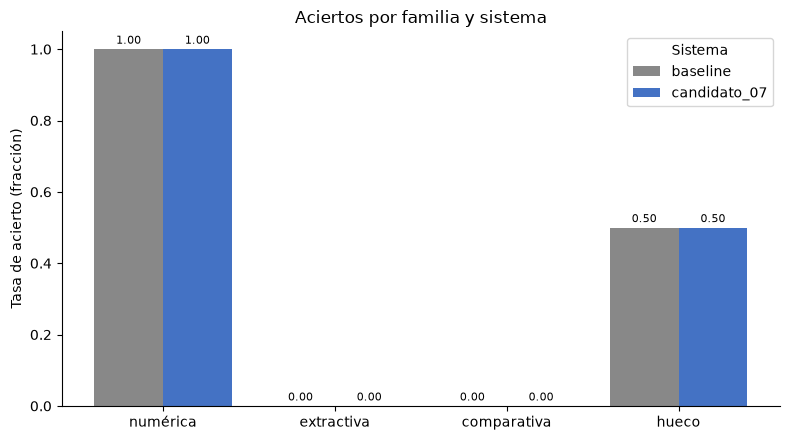

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SISTEMA_COLOR = {'baseline': '#888888', 'candidato_07': '#4472c4', 'final': '#1f8a4c'}


def _color(sistema):
    return SISTEMA_COLOR.get(sistema, '#c0392b')


# (a) Aciertos por familia y sistema: numérica/extractiva/comparativa salen de ETIQUETAS (golden propio,
# 20 preguntas); "hueco" sale de la variante '_huecos' de cada sistema (golden_huecos.jsonl, 6 preguntas),
# solo si ya se evaluó. Ninguna se inventa: si no existe el resumen, ese sistema no entra en la familia.
ETIQUETAS_HUECOS = tuple(s + '_huecos' for s in ETIQUETAS if (config.RESULTADOS / f'{s}_huecos' / 'resumen.json').is_file())
tabla_huecos = tabla_comparativa(ETIQUETAS_HUECOS) if ETIQUETAS_HUECOS else comparacion.iloc[0:0]

FAMILIAS_PROPIO = (('numérica', 'tasa_numerica'), ('extractiva', 'tasa_extractiva'), ('comparativa', 'tasa_comparativa'))
filas_familia = []
for _, fila in comparacion[comparacion['disponible']].iterrows():
    for familia, columna in FAMILIAS_PROPIO:
        filas_familia.append({'sistema': fila['sistema'], 'familia': familia, 'tasa': fila[columna]})
for _, fila in tabla_huecos[tabla_huecos['disponible']].iterrows():
    filas_familia.append({'sistema': fila['sistema'].removesuffix('_huecos'), 'familia': 'hueco', 'tasa': fila['tasa_hueco']})

tabla_familias = pd.DataFrame(filas_familia)
orden_familias = ['numérica', 'extractiva', 'comparativa', 'hueco']
pivote_familias = (tabla_familias.pivot(index='familia', columns='sistema', values='tasa')
                   .reindex(orden_familias))
sistemas_presentes = [s for s in ('baseline', 'candidato_07', 'final') if s in pivote_familias.columns]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(orden_familias))
ancho = 0.8 / max(len(sistemas_presentes), 1)
for i, sistema in enumerate(sistemas_presentes):
    valores = pivote_familias[sistema].to_numpy(dtype=float)
    offset = (i - (len(sistemas_presentes) - 1) / 2) * ancho
    barras = ax.bar(x + offset, valores, width=ancho, label=sistema, color=_color(sistema))
    ax.bar_label(barras, fmt=lambda v: f'{v:.2f}' if v == v else '', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(orden_familias)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Tasa de acierto (fracción)')
ax.set_title('Aciertos por familia y sistema')
ax.legend(title='Sistema')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

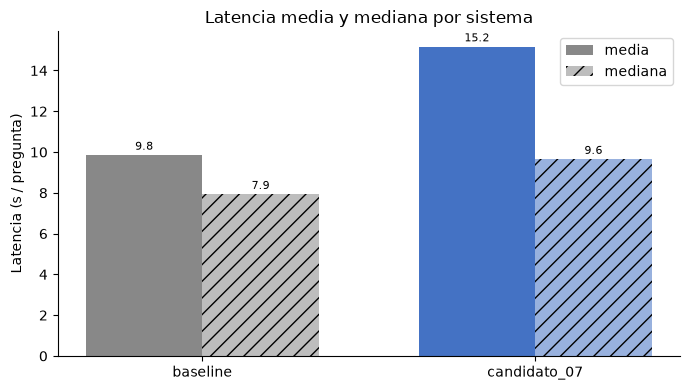

In [10]:
# (b) Latencia media y mediana por sistema (golden propio, 20 preguntas; segundos por pregunta).
disponibles = comparacion[comparacion['disponible']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(disponibles))
ancho = 0.35
media = disponibles['latencia_media_s'].to_numpy(dtype=float)
mediana = disponibles['latencia_mediana_s'].to_numpy(dtype=float)
barras_media = ax.bar(x - ancho / 2, media, width=ancho, label='media',
                      color=[_color(s) for s in disponibles['sistema']])
barras_mediana = ax.bar(x + ancho / 2, mediana, width=ancho, label='mediana',
                        color=[_color(s) for s in disponibles['sistema']], alpha=0.55, hatch='//')
ax.bar_label(barras_media, fmt=lambda v: f'{v:.1f}' if v == v else '', padding=2, fontsize=8)
ax.bar_label(barras_mediana, fmt=lambda v: f'{v:.1f}' if v == v else '', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(disponibles['sistema'])
ax.set_ylabel('Latencia (s / pregunta)')
ax.set_title('Latencia media y mediana por sistema')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

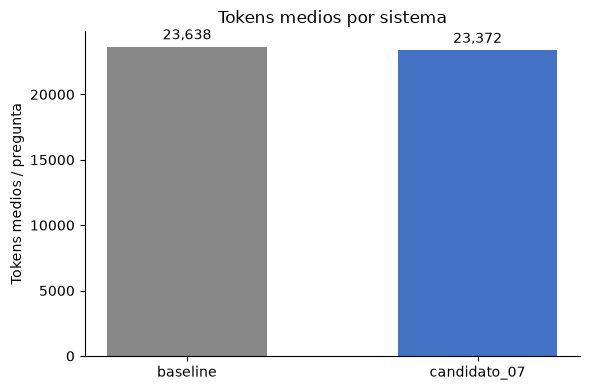

In [11]:
# (c) Tokens medios por sistema (golden propio, 20 preguntas; tokens totales por pregunta).
fig, ax = plt.subplots(figsize=(6, 4))
tokens = disponibles['tokens_medios'].to_numpy(dtype=float)
barras_tokens = ax.bar(disponibles['sistema'], tokens, color=[_color(s) for s in disponibles['sistema']], width=0.55)
ax.bar_label(barras_tokens, fmt=lambda v: f'{v:,.0f}' if v == v else '', padding=3)
ax.set_ylabel('Tokens medios / pregunta')
ax.set_title('Tokens medios por sistema')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 7. De candidato a final

Cuando termine el notebook 06:

1. implementar y probar `middleware_final()` (límite de llamadas + verificación XBRL);
2. confirmar que `final` monta retrieval mejorado y middleware no vacío;
3. ejecutar `evaluar(..., etiqueta='final', sistema='final')` sobre golden propio y huecos;
4. regenerar `tabla_comparativa(('baseline', 'final'))`;
5. actualizar informe y documentación con las métricas reales;
6. repetir pruebas, escaneo de claves y ensayo en clon limpio.

Hasta entonces, toda tabla baseline/candidato lleva la etiqueta **provisional, sin guardrails**.

## 8. Checklist de salida

- [x] El baseline no se sobrescribe.
- [x] El candidato usa retrieval mejorado y conserva las cuatro firmas públicas.
- [x] El final no degrada silenciosamente a baseline.
- [x] El notebook ejecuta sin red con `EJECUTAR=False`.
- [x] Gráficos de aciertos por familia, latencia y tokens, con `final` incorporándose solo cuando exista.
- [ ] Golden completo del candidato ejecutado y revisado.
- [ ] Notebook 06 integrado y sus pruebas superadas.
- [ ] Resultados finales, tabla R11 e informe regenerados.
- [ ] Clon limpio y presentación ensayados.